# **Tarea 1: Introducción a las series de tiempo**

## **1.2. Datos transversales**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
sns.set_style("darkgrid")

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Analisis y Predicción de series de tiempo/Data/WDIData.csv')
print('Column names:', data.columns)

Column names: Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', 'Unnamed: 61'],
      dtype='object')


In [ ]:
print('No. of rows, columns:', data.shape)

No. of rows, columns: (401016, 62)


In [ ]:
nb_countries = data['Country Code'].unique().shape[0]
print('Unique number of countries:', nb_countries)

Unique number of countries: 264


In [ ]:
data.dtypes

,0
Country Name,object
Country Code,object
Indicator Name,object
Indicator Code,object
1960,float64
...,...
2013,float64
2014,float64
2015,float64
2016,float64


In [ ]:
central_govt_debt = data.loc[data['Indicator Name']=='Central government debt, total (% of GDP)']
military_exp = data.loc[data['Indicator Name']=='Military expenditure (% of GDP)']

In [ ]:
print('Shape of central_govt_debt:', central_govt_debt.shape)
print('Shape of military_exp:', military_exp.shape)

Shape of central_govt_debt: (264, 62)
Shape of military_exp: (264, 62)


In [ ]:
central_govt_debt['2010'].describe()

,2010
count,94.000000
mean,53.048479
std,29.790674
min,0.519665
25%,28.357797
50%,49.540245
75%,75.259012
max,161.596402


In [ ]:
military_exp['2010'].describe()

,2010
count,192.000000
mean,1.988556
std,1.354856
min,0.000000
25%,1.190287
50%,1.613407
75%,2.624711
max,8.565679


In [ ]:
central_govt_debt.index = central_govt_debt['Country Code']
military_exp.index = military_exp['Country Code']

In [ ]:
central_govt_debt_2010 = central_govt_debt['2010'].loc[~pd.isnull(central_govt_debt['2010'])]
military_exp_2010 = military_exp['2010'].loc[~pd.isnull(military_exp['2010'])]

In [ ]:
central_govt_debt_2010

,2010
Country Code,
CEB,47.446156
EMU,72.414709
ECS,63.137736
ECA,22.338687
TEC,27.287492
...,...
UGA,27.552595
UKR,29.969556
GBR,83.406797


In [ ]:
military_exp_2010

,2010
Country Code,
ARB,5.117807
CEB,1.482543
EAR,2.335511
EAS,1.563325
EAP,1.724963
...,...
VEN,0.853924
VNM,2.305049
YEM,4.685557


In [ ]:
data_to_plot = pd.concat((central_govt_debt_2010, military_exp_2010), axis=1)
data_to_plot.columns = ['central_govt_debt', 'military_exp']

In [ ]:
data_to_plot.head()

,central_govt_debt,military_exp
Country Code,,
CEB,47.446156,1.482543
EMU,72.414709,1.618759
ECS,63.137736,1.860343
ECA,22.338687,2.933044
TEC,27.287492,2.785617


In [ ]:
data_to_plot.shape

(202, 2)

In [ ]:
df_ordenado = data_to_plot.sort_values(by='military_exp', ascending=False)
df_ordenado.head(10)

,central_govt_debt,military_exp
Country Code,,
SAU,NaN,8.565679
OMN,5.039094,8.347635
ISR,NaN,6.228475
ARE,NaN,6.038592
JOR,61.373457,5.895421
TCD,NaN,5.778139
ARB,NaN,5.117807
MEA,NaN,4.804054
YEM,NaN,4.685557


In [ ]:
data_to_plot = data_to_plot.loc[(~pd.isnull(data_to_plot.central_govt_debt)) & (~pd.isnull(data_to_plot.military_exp)), :]

In [ ]:
data_to_plot.head()

,central_govt_debt,military_exp
Country Code,,
CEB,47.446156,1.482543
EMU,72.414709,1.618759
ECS,63.137736,1.860343
ECA,22.338687,2.933044
TEC,27.287492,2.785617


In [ ]:
data_to_plot.shape

(84, 2)

In [ ]:
df_ordenado = data_to_plot.sort_values(by='military_exp', ascending=False)
df_ordenado.head(10)

,central_govt_debt,military_exp
Country Code,,
OMN,5.039094,8.347635
JOR,61.373457,5.895421
USA,85.601594,4.665615
NAC,82.576224,4.328041
GEO,36.799720,3.902453
RUS,9.098114,3.850719
COL,72.337793,3.631149
NAM,16.944972,3.514744
SGP,102.903421,3.429849


In [ ]:
df_ordenado = data_to_plot.sort_values(by='military_exp', ascending=False)
df_ordenado.head(10)

,central_govt_debt,military_exp
Country Code,,
OMN,5.039094,8.347635
JOR,61.373457,5.895421
USA,85.601594,4.665615
NAC,82.576224,4.328041
GEO,36.799720,3.902453
RUS,9.098114,3.850719
COL,72.337793,3.631149
NAM,16.944972,3.514744
SGP,102.903421,3.429849


In [ ]:
military_exp_np = np.array(data_to_plot.military_exp)

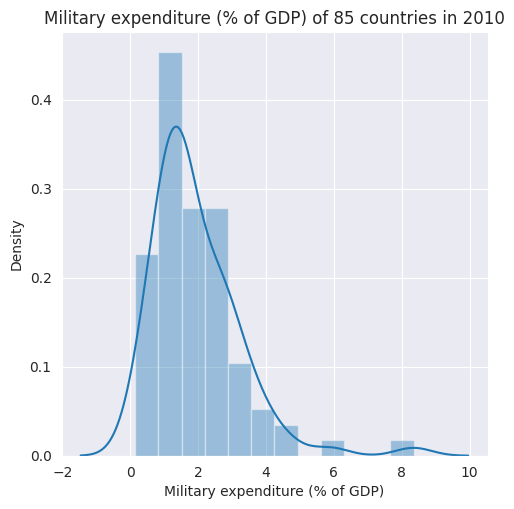

In [ ]:
plt.figure(figsize=(5.5, 5.5))
g = sns.distplot(military_exp_np, norm_hist=False)
g.set_title('Military expenditure (% of GDP) of 85 countries in 2010');
plt.xlabel("Military expenditure (% of GDP)");

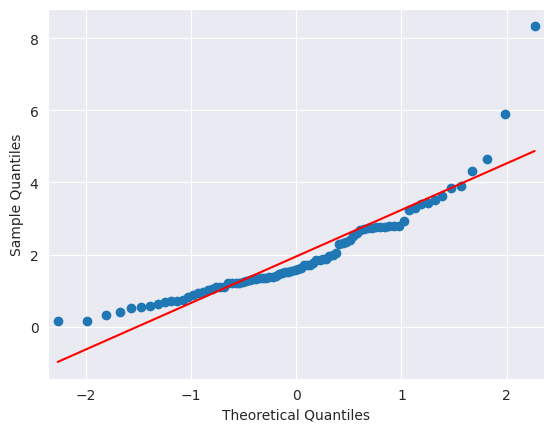

In [ ]:
from statsmodels.graphics.gofplots import qqplot
qqplot(military_exp_np, line='s');

In [ ]:
from scipy.stats import shapiro

print('Shapiro-Wilk Test:')
stat, p = shapiro(military_exp_np)
print('Statistics=%.6f, p=%e' % (stat, p))

alpha = 0.05
if p > alpha:
 print('Sample looks Normal (fail to reject H0)')
else:
 print('Sample does not look Normal (reject H0)')

Shapiro-Wilk Test:
Statistics=0.857023, p=1.646573e-07
Sample does not look Normal (reject H0)


In [ ]:
import numpy as np
from scipy import stats

print('Kolmogorov-Smirnov:')
stat, p = stats.kstest(military_exp_np, stats.norm.cdf)
print('Statistics=%.6f, p=%e' % (stat, p))

alpha = 0.05
if p > alpha:
 print('Sample looks Normal (fail to reject H0)')
else:
 print('Sample does not look Normal (reject H0)')

Kolmogorov-Smirnov:
Statistics=0.659326, p=2.320049e-36
Sample does not look Normal (reject H0)


In [ ]:
from scipy.stats import normaltest, kurtosis, skew

stat, p = normaltest(military_exp_np)
print('Statistics=%.3f, p=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
 print('Sample looks Gaussian (fail to reject H0)')
else:
 print('Sample does not look Gaussian (reject H0)')

print('Kurtosis=%.3f'%kurtosis(military_exp_np))
print('Skew=%.3f'%skew(military_exp_np))

Statistics=49.874, p=0.000
Sample does not look Gaussian (reject H0)
Kurtosis=6.122
Skew=1.916


## **1.3. Datos de series temporales**

In [ ]:
central_govt_debt_us = central_govt_debt.loc[central_govt_debt['Country Code']=='USA', :].T
military_exp_us = military_exp.loc[military_exp['Country Code']=='USA', :].T

In [ ]:
data_us = pd.concat((military_exp_us, central_govt_debt_us), axis=1)
index0 = np.where(data_us.index=='1960')[0][0]
index1 = np.where(data_us.index=='2010')[0][0]
data_us = data_us.iloc[index0:index1+1,:]
data_us.columns = ['Federal Military Expenditure', 'Debt of Federal Government']
data_us.head()

,Federal Military Expenditure,Debt of Federal Government
1960,8.35266,NaN
1961,8.487129,NaN
1962,8.656586,NaN
1963,8.189007,NaN
1964,7.467629,NaN


In [ ]:
data_us.isna().sum()

,0
Federal Military Expenditure,0
Debt of Federal Government,29


In [ ]:
(data_us.isnull().sum()/len(data_us))*100

,0
Federal Military Expenditure,0.000000
Debt of Federal Government,56.862745


In [ ]:
data_us['backward_fill'] = data_us['Debt of Federal Government'].bfill()
data_us.head()

,Federal Military Expenditure,Debt of Federal Government,backward_fill
1960,8.35266,NaN,39.016963
1961,8.487129,NaN,39.016963
1962,8.656586,NaN,39.016963
1963,8.189007,NaN,39.016963
1964,7.467629,NaN,39.016963


In [ ]:
data_us['mean_fill'] = data_us['Debt of Federal Government'].mean()
data_us.head()

,Federal Military Expenditure,Debt of Federal Government,backward_fill,mean_fill
1960,8.35266,NaN,39.016963,51.155537
1961,8.487129,NaN,39.016963,51.155537
1962,8.656586,NaN,39.016963,51.155537
1963,8.189007,NaN,39.016963,51.155537
1964,7.467629,NaN,39.016963,51.155537


In [ ]:
data_us['median_fill'] = data_us['Debt of Federal Government'].median()
data_us.head()

,Federal Military Expenditure,Debt of Federal Government,backward_fill,mean_fill,median_fill
1960,8.35266,NaN,39.016963,51.155537,47.659404
1961,8.487129,NaN,39.016963,51.155537,47.659404
1962,8.656586,NaN,39.016963,51.155537,47.659404
1963,8.189007,NaN,39.016963,51.155537,47.659404
1964,7.467629,NaN,39.016963,51.155537,47.659404


In [ ]:
data_us['quadratic_fill'] = data_us['Debt of Federal Government'].interpolate(option='quadratic')
data_us.head()

,Federal Military Expenditure,Debt of Federal Government,backward_fill,mean_fill,median_fill,quadratic_fill
1960,8.35266,NaN,39.016963,51.155537,47.659404,NaN
1961,8.487129,NaN,39.016963,51.155537,47.659404,NaN
1962,8.656586,NaN,39.016963,51.155537,47.659404,NaN
1963,8.189007,NaN,39.016963,51.155537,47.659404,NaN
1964,7.467629,NaN,39.016963,51.155537,47.659404,NaN


In [ ]:
data_us.dropna(inplace=True)
print('Shape of data_us:', data_us.shape)

Shape of data_us: (22, 6)


In [ ]:
data_us.head(10)

,Federal Military Expenditure,Debt of Federal Government,backward_fill,mean_fill,median_fill,quadratic_fill
1989,5.374717,39.016963,39.016963,51.155537,47.659404,39.016963
1990,5.120252,40.821367,40.821367,51.155537,47.659404,40.821367
1991,4.539845,43.948026,43.948026,51.155537,47.659404,43.948026
1992,4.666265,45.916542,45.916542,51.155537,47.659404,45.916542
1993,4.326925,48.104749,48.104749,51.155537,47.659404,48.104749
1994,3.941287,47.21406,47.214060,51.155537,47.659404,47.21406
1995,3.638489,47.059783,47.059783,51.155537,47.659404,47.059783
1996,3.350744,46.585511,46.585511,51.155537,47.659404,46.585511
1997,3.209903,43.958801,43.958801,51.155537,47.659404,43.958801
1998,3.017636,41.009914,41.009914,51.155537,47.659404,41.009914


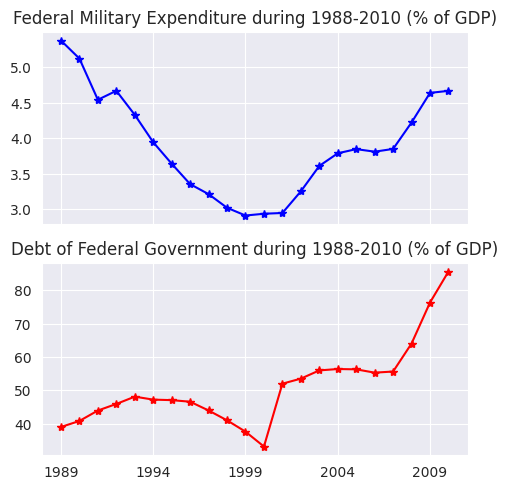

In [ ]:
f, axarr = plt.subplots(2, sharex=True)
f.set_size_inches(5.5, 5.5)
axarr[0].set_title('Federal Military Expenditure during 1988-2010 (% of GDP)')
data_us['Federal Military Expenditure'].plot(linestyle='-', marker='*', color='b', ax=axarr[0])
axarr[1].set_title('Debt of Federal Government during 1988-2010 (% of GDP)')
data_us['Debt of Federal Government'].plot(linestyle='-', marker='*', color='r', ax=axarr[1]);

## **1.4. Datos de panel**

In [ ]:
chn = data.loc[(data['Indicator Name']=='Military expenditure (% of GDP)') & \
               (data['Country Code']=='CHN'), :] #China
chn.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2008,2009,2010,2011,2012,2013,2014,2015,2016,Unnamed: 61
134507,China,CHN,Military expenditure (% of GDP),MS.MIL.XPND.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,1.878156,2.067426,1.896713,1.821927,1.838564,1.872334,1.915341,1.934922,1.922962,NaN


In [ ]:
chn = data.loc[(data['Indicator Name']=='Military expenditure (% of GDP)') & \
               (data['Country Code']=='CHN'), :].drop(data.columns[range(3)], axis=1)
chn.head()

,Indicator Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2008,2009,2010,2011,2012,2013,2014,2015,2016,Unnamed: 61
134507,MS.MIL.XPND.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.878156,2.067426,1.896713,1.821927,1.838564,1.872334,1.915341,1.934922,1.922962,NaN


In [ ]:
chn = pd.Series(data=chn.values[0], index=chn.columns)
chn.dropna(inplace=True)
chn.head()

,0
Indicator Code,MS.MIL.XPND.GD.ZS
1989,2.499185
1990,2.555996
1991,2.407892
1992,2.518629


In [ ]:
usa = data.loc[(data['Indicator Name']=='Military expenditure (% of GDP)') & \
               (data['Country Code']=='USA'), :].drop(data.columns[range(3)], axis=1) #USA
usa = pd.Series(data=usa.values[0], index=usa.columns)
usa.dropna(inplace=True)
usa.head()

,0
Indicator Code,MS.MIL.XPND.GD.ZS
1960,8.35266
1961,8.487129
1962,8.656586
1963,8.189007


In [ ]:
ind = data.loc[(data['Indicator Name']=='Military expenditure (% of GDP)') & \
               (data['Country Code']=='IND'), :].drop(data.columns[range(3)], axis=1) #India
ind = pd.Series(data=ind.values[0], index=ind.columns)
ind.dropna(inplace=True)
ind.head()

,0
Indicator Code,MS.MIL.XPND.GD.ZS
1960,1.866015
1961,1.933365
1962,2.561202
1963,3.758057


In [ ]:
gbr = data.loc[(data['Indicator Name']=='Military expenditure (% of GDP)') & \
               (data['Country Code']=='GBR'), :].drop(data.columns[range(3)], axis=1) #United Kingdom
gbr = pd.Series(data=gbr.values[0], index=gbr.columns)
gbr.dropna(inplace=True)
gbr.head()

,0
Indicator Code,MS.MIL.XPND.GD.ZS
1960,6.343041
1961,6.190022
1962,6.210394
1963,6.082126


In [ ]:
n_years = chn.shape[0]
print("#Years: ", n_years+1)

#Years:  30


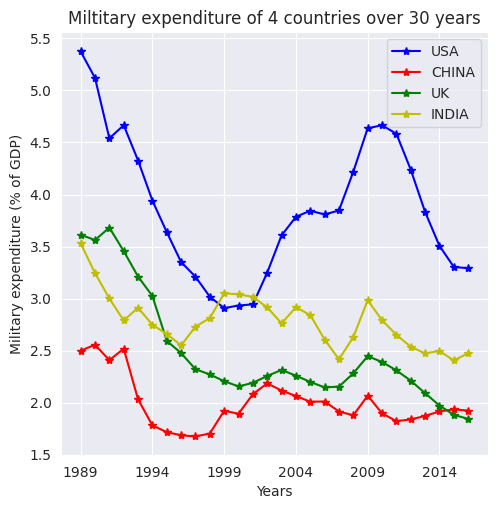

In [ ]:
plt.figure(figsize=(5.5, 5.5))
usa[n_years+1:2*n_years].plot(linestyle='-', marker='*', color='b')
chn[1:n_years].plot(linestyle='-', marker='*', color='r')
gbr[n_years+1:2*n_years].plot(linestyle='-', marker='*', color='g')
ind[n_years+1:2*n_years].plot(linestyle='-', marker='*', color='y')
plt.legend(['USA','CHINA','UK','INDIA'], loc=1)
plt.title('Miltitary expenditure of 4 countries over 30 years')
plt.ylabel('Military expenditure (% of GDP)')
plt.xlabel('Years');

## **1.5. Estructuras internas de las series temporales**

En esta sección se tiene un abordaje conceptual de las siguientes características especiales de los datos de series temporales que requieren un tratamiento matemático especial:


*   Tendencia general
*   Estacionalidad


*   Movimientos cíclicos
*   Componentes irregulares

## **1.6. Tendencia general**

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_excel('/content/drive/MyDrive/Analisis y Predicción de series de tiempo/Data/Monthly_CO2_Concentrations.xlsx', converters={'Year': np.int32, 'Month': np.int32})

In [ ]:
data.head()

,CO2,Year,Month
0,333.13,1974,5
1,332.09,1974,6
2,331.10,1974,7
3,329.14,1974,8
4,327.36,1974,9


In [ ]:
data.index = data['Year'].astype(str) + '-' + data['Month'].astype(str).map(lambda x: '0'+x if len(x) == 1 else x)
data.head()

,CO2,Year,Month
1974-05,333.13,1974,5
1974-06,332.09,1974,6
1974-07,331.10,1974,7
1974-08,329.14,1974,8
1974-09,327.36,1974,9


In [ ]:
data = data.loc[(~pd.isnull(data['CO2'])) & \
                (~pd.isnull(data['Year']))& \
                (~pd.isnull(data['Month']))]

In [ ]:
data.sort_values(['Year', 'Month'], inplace=True)

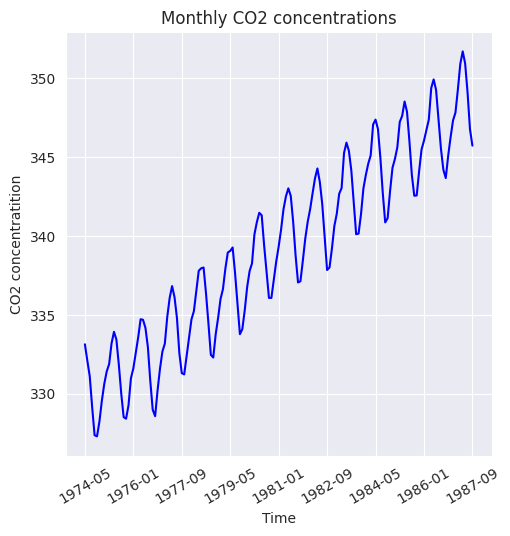

In [ ]:
plt.figure(figsize=(5.5, 5.5))
data['CO2'].plot(color='b')
plt.title('Monthly CO2 concentrations')
plt.xlabel('Time')
plt.ylabel('CO2 concentratition')
plt.xticks(rotation=30);

In [ ]:
data.index = pd.to_datetime(data.index, format='%Y-%m')
frecuencia = pd.infer_freq(data.index)
print("Frecuencia: ", frecuencia)

Frecuencia:  MS


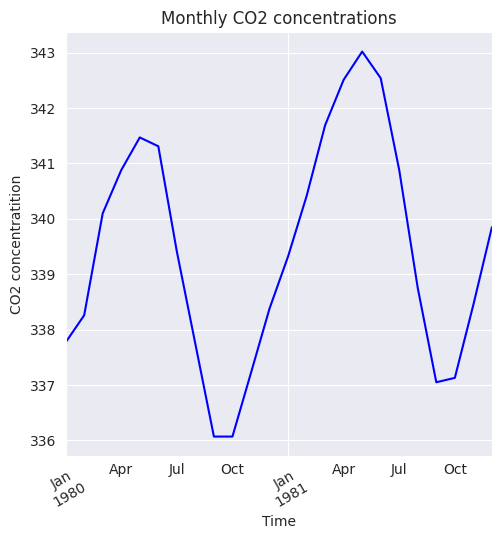

In [ ]:
plt.figure(figsize=(5.5, 5.5))
data['CO2'].loc[(data['Year']==1980) | (data['Year']==1981)].plot(color='b')
plt.title('Monthly CO2 concentrations')
plt.xlabel('Time')
plt.ylabel('CO2 concentratition')
plt.xticks(rotation=30);

In [ ]:
!pip install -U scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 30.8 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

In [ ]:
trend_model = LinearRegression(fit_intercept=True)
trend_model.fit(np.arange(data.shape[0]).reshape((-1,1)), data['CO2'])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
print('Trend model coefficient={} and intercept={}'.format(trend_model.coef_[0], trend_model.intercept_))

Trend model coefficient=0.1209930124223602 and intercept=329.45310559006214


In [ ]:
residuals = np.array(data['CO2']) - trend_model.predict(np.arange(data.shape[0]).reshape((-1,1)))

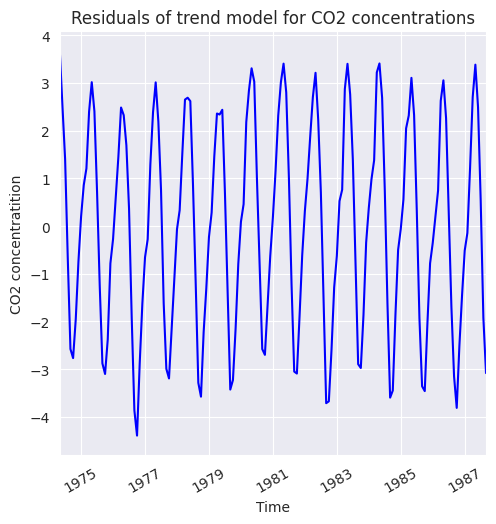

In [ ]:
plt.figure(figsize=(5.5, 5.5))
pd.Series(data=residuals, index=data.index).plot(color='b')
plt.title('Residuals of trend model for CO2 concentrations')
plt.xlabel('Time')
plt.ylabel('CO2 concentratition')
plt.xticks(rotation=30);

## **1.7. Estacionalidad**

## **1.8. Gráfico de secuencia de series**

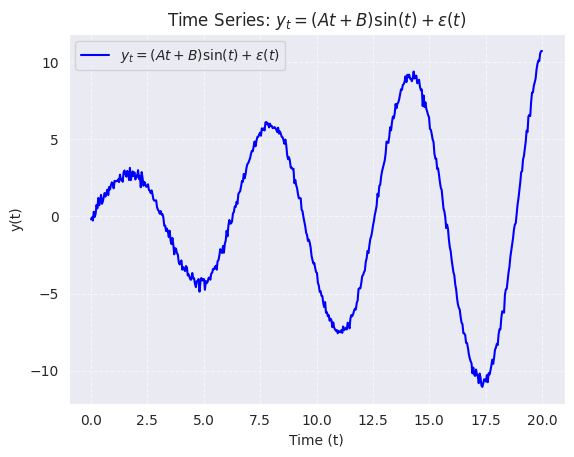

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

A = 0.5
B = 2.0
t = np.linspace(0, 20, 500)
epsilon = np.random.normal(0, 0.2, len(t))

y_t = (A * t + B) * np.sin(t) + epsilon

plt.figure()
plt.plot(t, y_t, label=r'$y_{t} = (At + B)\sin(t) + \varepsilon(t)$', color='blue')
plt.title("Time Series: $y_{t} = (At + B)\\sin(t) + \\varepsilon(t)$")
plt.xlabel("Time (t)")
plt.ylabel("y(t)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

## **1.9. Gráfico de subserie estacional**

In [ ]:
data.head()

,CO2,Year,Month
1974-05-01,333.13,1974,5
1974-06-01,332.09,1974,6
1974-07-01,331.10,1974,7
1974-08-01,329.14,1974,8
1974-09-01,327.36,1974,9


In [ ]:
data['Residuals'] = residuals
month_quarter_map = {1: 'Q1', 2: 'Q1', 3: 'Q1',
                     4: 'Q2', 5: 'Q2', 6: 'Q2',
                     7: 'Q3', 8: 'Q3', 9: 'Q3',
                     10: 'Q4', 11: 'Q4', 12: 'Q4'}
data['Quarter'] = data['Month'].map(lambda m: month_quarter_map.get(m))

In [ ]:
seasonal_sub_series_data = data.groupby(by=['Year', 'Quarter'])['Residuals'].aggregate([np.mean, np.std])
seasonal_sub_series_data.columns = ['Quarterly Mean', 'Quarterly Standard Deviation']

In [ ]:
seasonal_sub_series_data.reset_index(inplace=True)
seasonal_sub_series_data.index = seasonal_sub_series_data['Year'].astype(str) + '-' + seasonal_sub_series_data['Quarter']
seasonal_sub_series_data.head()

,Year,Quarter,Quarterly Mean,Quarterly Standard Deviation
1974-Q2,1974,Q2,3.096398,0.820946
1974-Q3,1974,Q3,-0.616085,1.991671
1974-Q4,1974,Q4,-1.822397,1.014952
1975-Q1,1975,Q1,0.754624,0.511890
1975-Q2,1975,Q2,2.604978,0.355093


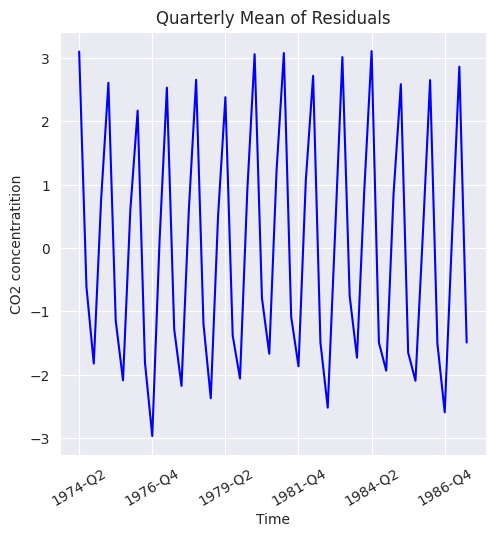

In [ ]:
plt.figure(figsize=(5.5, 5.5))
seasonal_sub_series_data['Quarterly Mean'].plot(color='b')
plt.title('Quarterly Mean of Residuals')
plt.xlabel('Time')
plt.ylabel('CO2 concentratition')
plt.xticks(rotation=30);

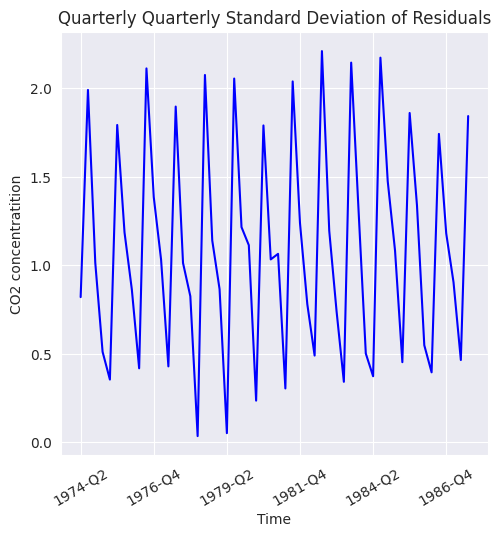

In [ ]:
plt.figure(figsize=(5.5, 5.5))
seasonal_sub_series_data['Quarterly Standard Deviation'].plot(color='b')
plt.title('Quarterly Quarterly Standard Deviation of Residuals')
plt.xlabel('Time')
plt.ylabel('CO2 concentratition')
plt.xticks(rotation=30);

## **1.10. Gráficos de cajas múltiples**

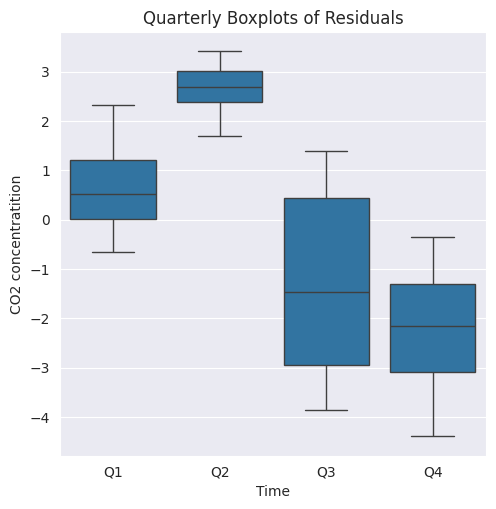

In [ ]:
plt.figure(figsize=(5.5, 5.5))
g = sns.boxplot(data=data[data['Year'] > 1974], y='Residuals', x='Quarter')
g.set_title('Quarterly Boxplots of Residuals')
g.set_xlabel('Time')
g.set_ylabel('CO2 concentratition');

## **1.11. Cambios cíclicos**

In [ ]:
inflation = pd.read_excel('/content/drive/MyDrive/Analisis y Predicción de series de tiempo/Data/inflation-consumer-prices-annual.xlsx', parse_dates=['Year'])

In [ ]:
inflation.head()

,Year,India,United States
0,1960-01-01,1.783265,1.509929
1,1961-01-01,1.752022,1.075182
2,1962-01-01,3.576159,1.116071
3,1963-01-01,2.941176,1.214128
4,1964-01-01,13.354037,1.308615


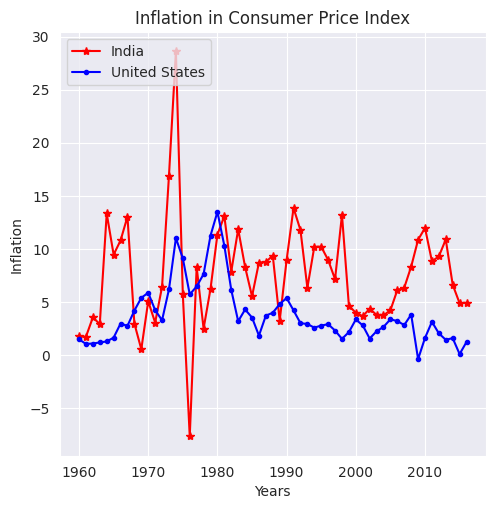

In [ ]:
plt.figure(figsize=(5.5, 5.5))
plt.plot(range(1960,2017), inflation['India'], linestyle='-', marker='*', color='r')
plt.plot(range(1960,2017), inflation['United States'], linestyle='-', marker='.', color='b')
plt.legend(['India','United States'], loc=2)
plt.title('Inflation in Consumer Price Index')
plt.ylabel('Inflation')
plt.xlabel('Years');

## **1.12. Componentes irregulares**

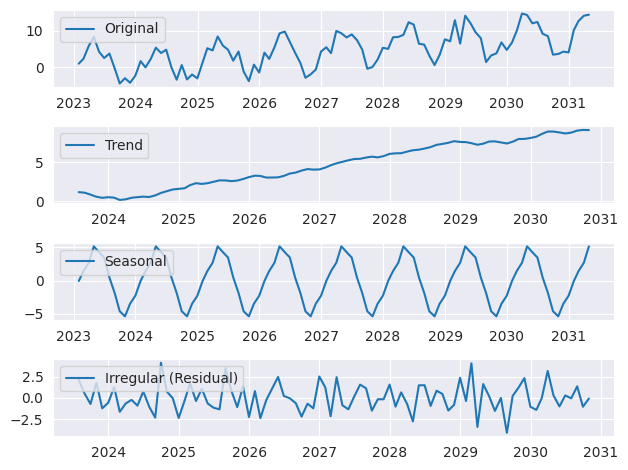

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

np.random.seed(42)
n = 100
time = np.arange(n)

trend = 0.1 * time
seasonality = 5 * np.sin(2 * np.pi * time / 12)
irregular = np.random.normal(0, 2, n)

series = trend + seasonality + irregular

date_range = pd.date_range(start="2023-01-01", periods=n, freq='M')
data = pd.DataFrame({'Date': date_range, 'Value': series}).set_index('Date')

decomposition = seasonal_decompose(data['Value'], model='additive', period=12)

plt.figure()
plt.subplot(411)
plt.plot(data['Value'], label='Original')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(decomposition.trend, label='Trend')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonal')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(decomposition.resid, label='Irregular (Residual)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## **1.13. Modelos de análisis de series temporales**

## **1.14. Modelos de media cero**

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [ ]:
np.random.seed(42)
zero_mean_series = np.random.normal(loc=0.0, scale=1., size=100)

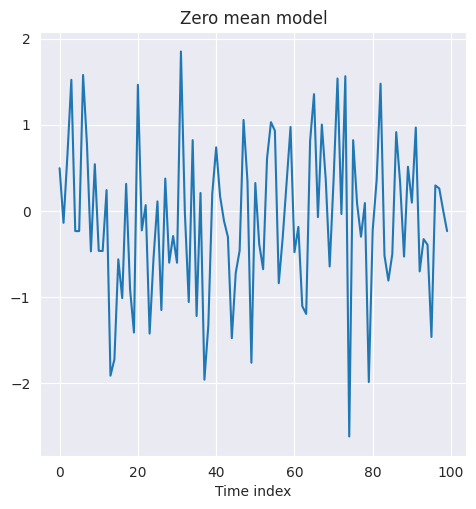

In [ ]:
plt.figure(figsize=(5.5, 5.5))
g = sns.lineplot(zero_mean_series)
g.set_title('Zero mean model')
g.set_xlabel('Time index');

## **1.15. Camino aleatorio**

In [ ]:
random_walk = np.cumsum(zero_mean_series)

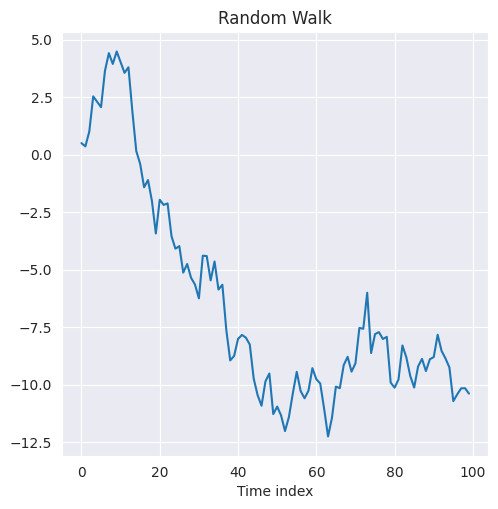

In [ ]:
plt.figure(figsize=(5.5, 5.5))
g = sns.lineplot(random_walk)
g.set_title('Random Walk')
g.set_xlabel('Time index');

## **1.16. Modelos de tendencia**

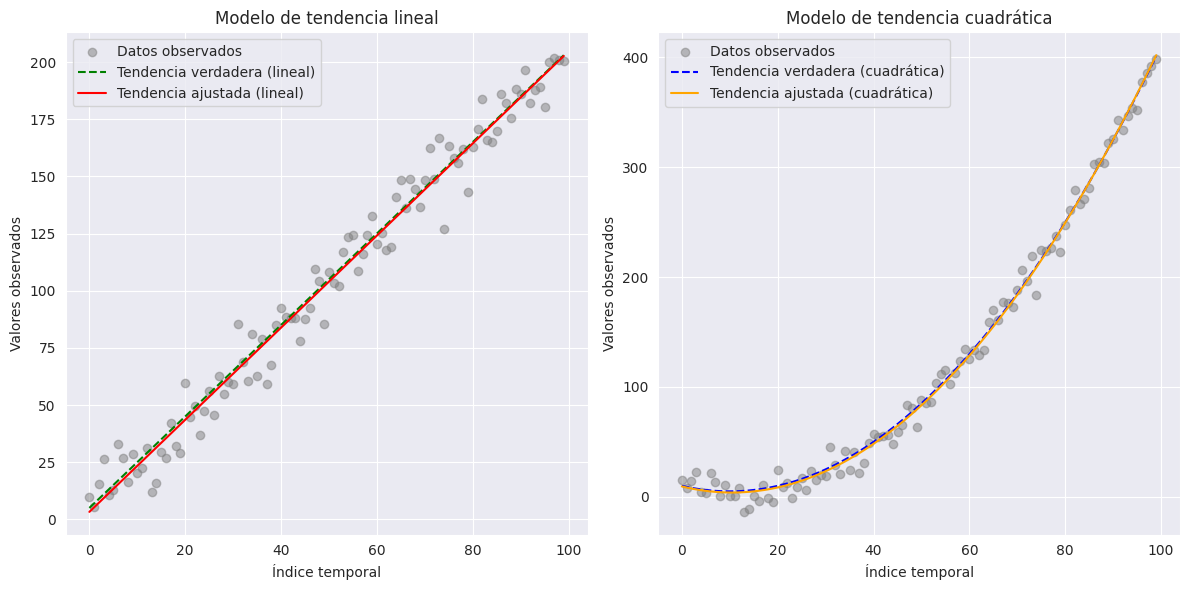

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


np.random.seed(42)
t = np.arange(0, 100, 1)
true_trend_linear = 2 * t + 5  # Modelo de tendencia lineal: µ(t) = 2t + 5
true_trend_quadratic = 0.05 * t**2 - t + 10  # Modelo cuadrático: µ(t) = 0.05t^2 - t + 10

noise = np.random.normal(0, 10, size=len(t))
y_linear = true_trend_linear + noise  # Serie con tendencia lineal
y_quadratic = true_trend_quadratic + noise  # Serie con tendencia cuadrática

# Modelo lineal: y = wt + b
coeffs_linear = np.polyfit(t, y_linear, 1)  # Grado 1
fitted_trend_linear = np.polyval(coeffs_linear, t)

# Modelo cuadrático: y = w1t + w2t^2 + b
coeffs_quadratic = np.polyfit(t, y_quadratic, 2)  # Grado 2
fitted_trend_quadratic = np.polyval(coeffs_quadratic, t)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(t, y_linear, color='gray', alpha=0.5, label='Datos observados')
plt.plot(t, true_trend_linear, color='green', label='Tendencia verdadera (lineal)', linestyle='dashed')
plt.plot(t, fitted_trend_linear, color='red', label='Tendencia ajustada (lineal)')
plt.title('Modelo de tendencia lineal')
plt.xlabel('Índice temporal')
plt.ylabel('Valores observados')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(t, y_quadratic, color='gray', alpha=0.5, label='Datos observados')
plt.plot(t, true_trend_quadratic, color='blue', label='Tendencia verdadera (cuadrática)', linestyle='dashed')
plt.plot(t, fitted_trend_quadratic, color='orange', label='Tendencia ajustada (cuadrática)')
plt.title('Modelo de tendencia cuadrática')
plt.xlabel('Índice temporal')
plt.ylabel('Valores observados')
plt.legend()

plt.tight_layout()
plt.show()

## **1.19. Experimentos numéricos ACF**

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [ ]:
url = "https://raw.githubusercontent.com/lihkir/Data/main/DJIA_Jan2016_Dec2016.xlsx"
djia_df = pd.read_excel(url)

In [ ]:
djia_df.index = djia_df['Date']
djia_df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,,
2016-01-04,2016-01-04,17405.480469,17405.480469,16957.630859,17148.939453,17148.939453,148060000
2016-01-05,2016-01-05,17147.500000,17195.839844,17038.609375,17158.660156,17158.660156,105750000
2016-01-06,2016-01-06,17154.830078,17154.830078,16817.619141,16906.509766,16906.509766,120250000
2016-01-07,2016-01-07,16888.359375,16888.359375,16463.630859,16514.099609,16514.099609,176240000
2016-01-08,2016-01-08,16519.169922,16651.890625,16314.570313,16346.450195,16346.450195,141850000


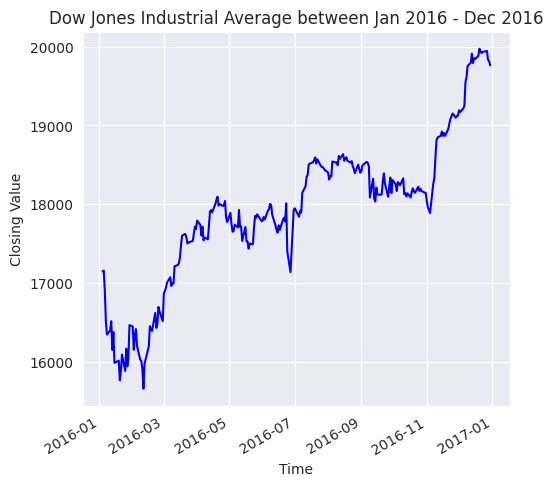

In [ ]:
plt.figure(figsize=(5.5, 5.5))
djia_df['Close'].plot(color='b')
plt.title('Dow Jones Industrial Average between Jan 2016 - Dec 2016')
plt.xlabel('Time')
plt.ylabel('Closing Value');

In [ ]:
lag = range(0,31)
djia_acf = []
for l in lag:
    djia_acf.append(djia_df['Close'].autocorr(l))

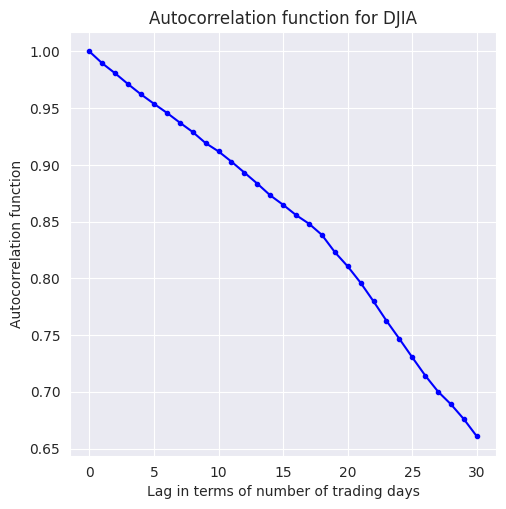

In [ ]:
plt.figure(figsize=(5.5, 5.5))
plt.plot(djia_acf, marker='.', color='b')
plt.title('Autocorrelation function for DJIA')
plt.xlabel('Lag in terms of number of trading days')
plt.ylabel('Autocorrelation function');

<Figure size 550x550 with 0 Axes>

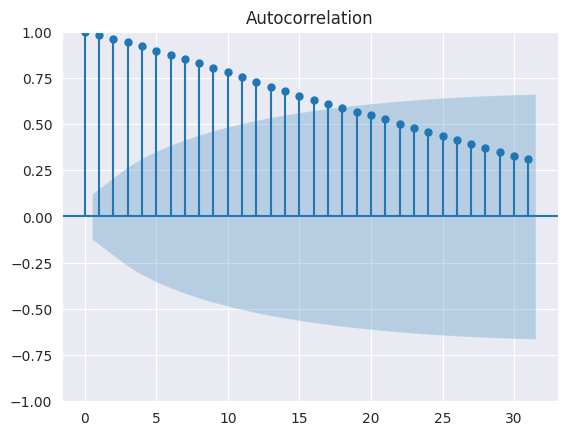

In [ ]:
plt.figure(figsize=(5.5, 5.5));
plot_acf(djia_df['Close'], lags=31);

<Figure size 550x550 with 0 Axes>

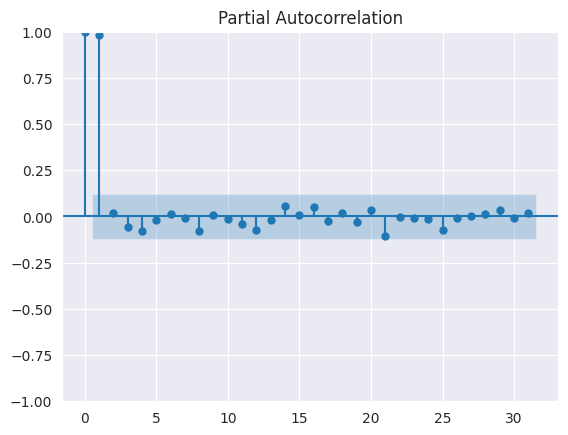

In [ ]:
plt.figure(figsize=(5.5, 5.5));
plot_pacf(djia_df['Close'], lags=31);

## **1.22. Remuestreo de datos de series temporales**

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Analisis y Predicción de series de tiempo/Data/chemical-concentration-readings.csv')
print('Shape of the dataset:', df.shape)
df.head()

Shape of the dataset: (197, 2)


,Timestamp,Chemical conc.
0,1975-01-01 00:00:00,17.0
1,1975-01-01 02:00:00,16.6
2,1975-01-01 04:00:00,16.3
3,1975-01-01 06:00:00,16.1
4,1975-01-01 08:00:00,17.1


In [ ]:
datetime_rowid = df['Timestamp'].map(lambda t: pd.to_datetime(t, format='%Y-%m-%d %H:%M:%S'))
df.index = datetime_rowid
df.head()

,Timestamp,Chemical conc.
Timestamp,,
1975-01-01 00:00:00,1975-01-01 00:00:00,17.0
1975-01-01 02:00:00,1975-01-01 02:00:00,16.6
1975-01-01 04:00:00,1975-01-01 04:00:00,16.3
1975-01-01 06:00:00,1975-01-01 06:00:00,16.1
1975-01-01 08:00:00,1975-01-01 08:00:00,17.1


In [ ]:
daily = df['Chemical conc.'].resample('D')
daily_mean = daily.mean()

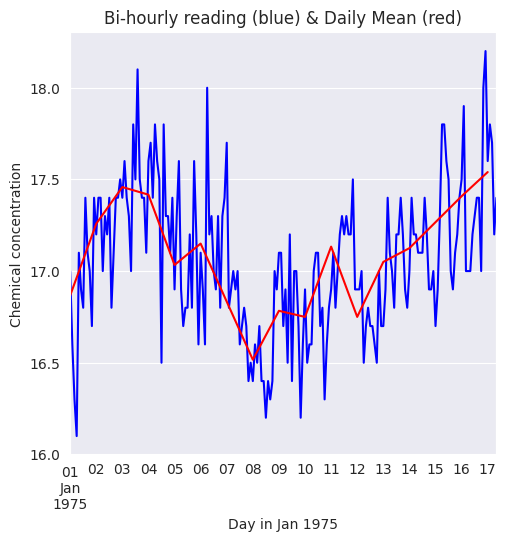

In [ ]:
fig = plt.figure(figsize=(5.5, 5.5))
ax = fig.add_subplot(1,1,1)
df['Chemical conc.'].plot(ax=ax, color='b')
daily_mean.plot(ax=ax, color='r')
ax.set_title('Bi-hourly reading (blue) & Daily Mean (red)');
ax.set_xlabel('Day in Jan 1975');
ax.set_ylabel('Chemical concentration');

## **1.23. Agregación por grupos**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Analisis y Predicción de series de tiempo/Data/mean-daily-temperature-fisher-river.csv')
df.index = df['Date'].map(lambda d: pd.to_datetime(d, format = '%Y-%m-%d'))

In [ ]:
print('Shape of dataframe:', df.shape)
df.head()

Shape of dataframe: (1461, 2)


,Date,Mean temperature
Date,,
1988-01-01,1988-01-01,-23.0
1988-01-02,1988-01-02,-20.5
1988-01-03,1988-01-03,-22.0
1988-01-04,1988-01-04,-30.5
1988-01-05,1988-01-05,-31.0


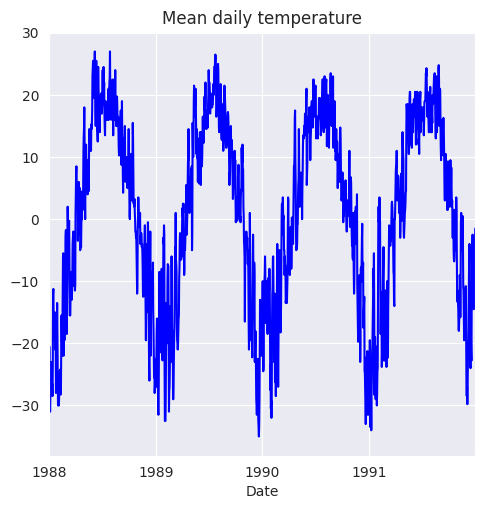

In [ ]:
fig = plt.figure(figsize=(5.5, 5.5))
ax = fig.add_subplot(1,1,1)
df['Mean temperature'].plot(ax=ax, color='b')
ax.set_title('Mean daily temperature');

In [ ]:
df['Month_Year'] = df.index.map(lambda d: d.strftime('%m-%Y'))
df.head()

,Date,Mean temperature,Month_Year
Date,,,
1988-01-01,1988-01-01,-23.0,01-1988
1988-01-02,1988-01-02,-20.5,01-1988
1988-01-03,1988-01-03,-22.0,01-1988
1988-01-04,1988-01-04,-30.5,01-1988
1988-01-05,1988-01-05,-31.0,01-1988


In [ ]:
monthly_stats = df.groupby(by='Month_Year')['Mean temperature'].aggregate([np.mean, np.median, np.std])
monthly_stats.reset_index(inplace=True)
monthly_stats.head()

,Month_Year,mean,median,std
0,01-1988,-22.137097,-23.0,5.260640
1,01-1989,-17.129032,-18.0,8.250725
2,01-1990,-15.112903,-12.0,6.606764
3,01-1991,-23.038710,-24.5,7.095570
4,02-1988,-19.025862,-19.5,8.598522


In [ ]:
monthly_stats['Year'] = monthly_stats['Month_Year']\
.map(lambda m: pd.to_datetime(m, format='%m-%Y').strftime('%Y'))

monthly_stats['Month'] = monthly_stats['Month_Year']\
.map(lambda m: pd.to_datetime(m, format='%m-%Y').strftime('%m'))

monthly_stats.sort_values(by=['Year', 'Month'], inplace=True)
monthly_stats.head()

,Month_Year,mean,median,std,Year,Month
0,01-1988,-22.137097,-23.000,5.260640,1988,01
4,02-1988,-19.025862,-19.500,8.598522,1988,02
8,03-1988,-8.258065,-9.250,5.341459,1988,03
12,04-1988,2.641667,1.875,5.057720,1988,04
16,05-1988,11.290323,11.000,6.254364,1988,05


In [ ]:
monthly_stats.index = monthly_stats['Month_Year']

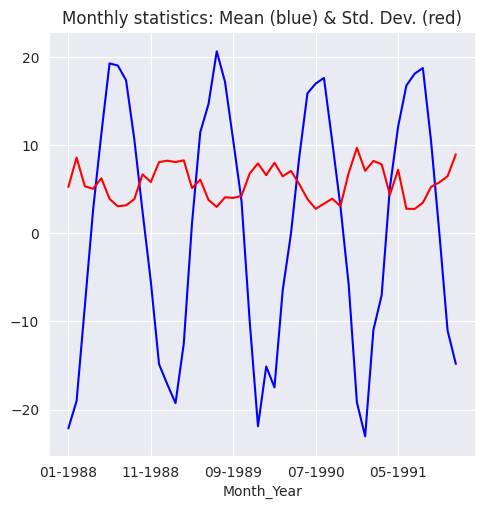

In [ ]:
fig = plt.figure(figsize=(5.5, 5.5))
ax = fig.add_subplot(1,1,1)

monthly_stats['mean'].plot(ax=ax, color='b')
monthly_stats['std'].plot(ax=ax, color='r')

ax.set_title('Monthly statistics: Mean (blue) & Std. Dev. (red)');

## **1.24. Estadísticos móviles**

In [ ]:
weekly_moving_average = df['Mean temperature'].rolling(7).mean()

In [ ]:
monthly_moving_average = df['Mean temperature'].rolling(30).mean()

In [ ]:
weekly_moving_average_2stride = df['Mean temperature'].rolling(7).mean()[::2]

In [ ]:
monthly_moving_average_2stride = df['Mean temperature'].rolling(30).mean()[::2]

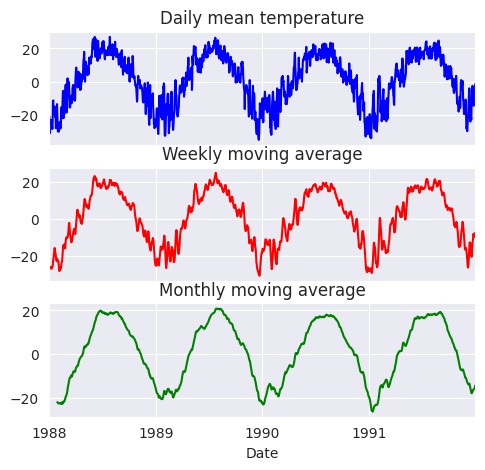

In [ ]:
fig, axarr = plt.subplots(3, sharex=True)
fig.set_size_inches(5.5, 5,5)

df['Mean temperature'].plot(ax=axarr[0], color='b')
axarr[0].set_title('Daily mean temperature');

weekly_moving_average.plot(ax=axarr[1], color='r')
axarr[1].set_title('Weekly moving average');

monthly_moving_average.plot(ax=axarr[2], color='g')
axarr[2].set_title('Monthly moving average');

## **1.25. Procesos estacionarios**

In [ ]:
from random import seed
from pandas import Series
import random
from pandas.plotting import autocorrelation_plot
import matplotlib.pyplot as plt

In [ ]:
seed(1)
series = [random.gauss(0.0, 1.0) for i in range(1000)]
series = Series(series)
series.describe()

,0
count,1000.000000
mean,-0.013222
std,1.003685
min,-2.961214
25%,-0.684192
50%,-0.010934
75%,0.703915
max,2.737260


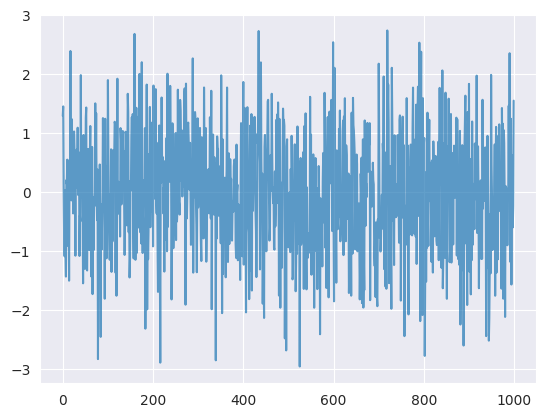

In [ ]:
series.plot(alpha=0.7);

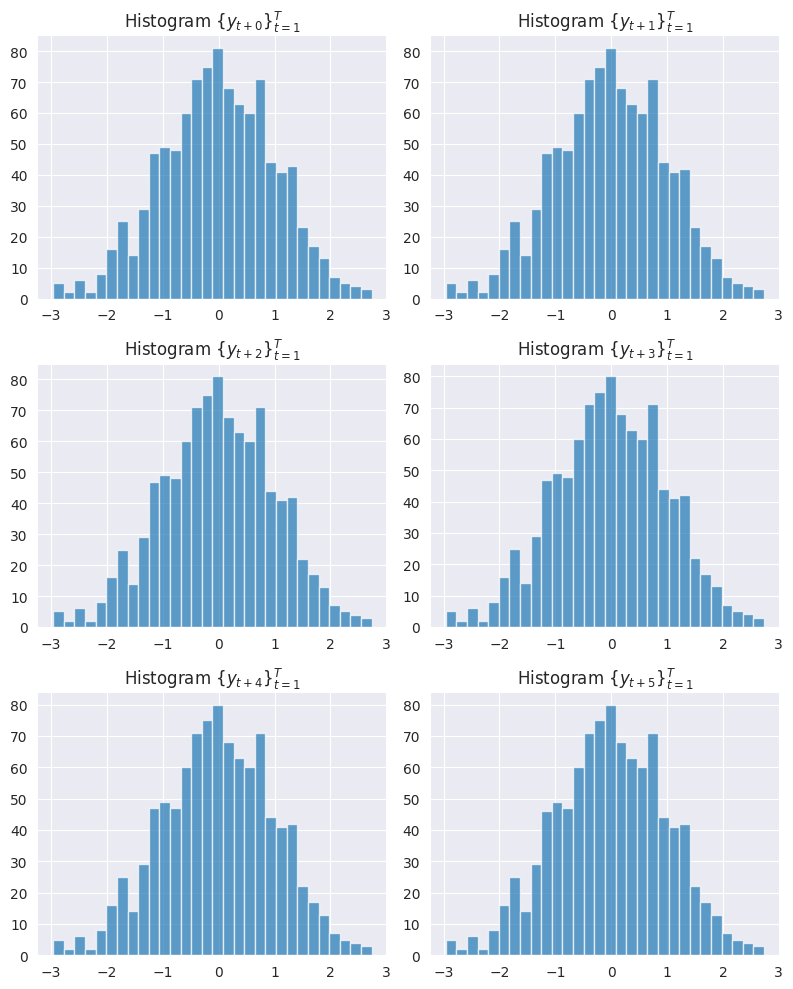

In [ ]:
plt.rcParams['text.usetex'] = False
fig, axs = plt.subplots(3, 2, figsize=(8, 10))

for i, ax in enumerate(axs.flat):
    ax.hist(series[i:], bins=30, alpha=0.7)
    ax.set_title(r'Histogram $\{y_{t+%d}\}_{t=1}^{T}$' % (i))

plt.tight_layout()
plt.show()
plt.rcParams['text.usetex'] = False

## **1.28. Diferenciación**

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa import stattools
from matplotlib import pyplot as plt
from pandas.plotting import autocorrelation_plot

In [ ]:
url = "https://raw.githubusercontent.com/lihkir/Data/main/DJIA_Jan2016_Dec2016.xlsx"
djia_df = pd.read_excel(url)

In [ ]:
djia_df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2016-01-04,17405.480469,17405.480469,16957.630859,17148.939453,17148.939453,148060000
1,2016-01-05,17147.500000,17195.839844,17038.609375,17158.660156,17158.660156,105750000
2,2016-01-06,17154.830078,17154.830078,16817.619141,16906.509766,16906.509766,120250000
3,2016-01-07,16888.359375,16888.359375,16463.630859,16514.099609,16514.099609,176240000
4,2016-01-08,16519.169922,16651.890625,16314.570313,16346.450195,16346.450195,141850000


In [ ]:
djia_df['Date'] = pd.to_datetime(djia_df['Date'], '%Y-%m-%d')
djia_df.index = djia_df['Date']
djia_df.drop('Date', axis=1, inplace=True)
djia_df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2016-01-04,17405.480469,17405.480469,16957.630859,17148.939453,17148.939453,148060000
2016-01-05,17147.500000,17195.839844,17038.609375,17158.660156,17158.660156,105750000
2016-01-06,17154.830078,17154.830078,16817.619141,16906.509766,16906.509766,120250000
2016-01-07,16888.359375,16888.359375,16463.630859,16514.099609,16514.099609,176240000
2016-01-08,16519.169922,16651.890625,16314.570313,16346.450195,16346.450195,141850000


In [ ]:
first_order_diff = djia_df['Close'].diff(1)

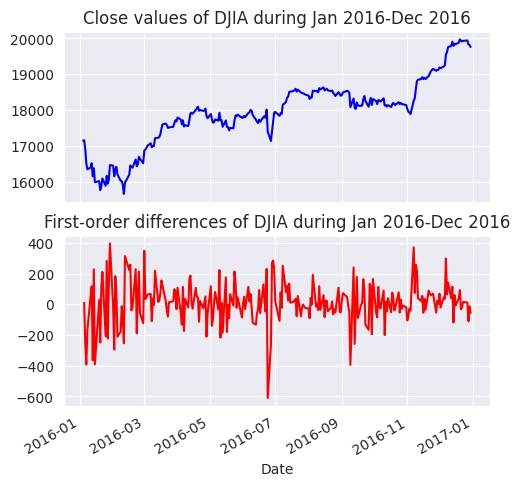

In [ ]:
fig, ax = plt.subplots(2, sharex=True)
fig.set_size_inches(5.5, 5.5)
djia_df['Close'].plot(ax=ax[0], color='b');
ax[0].set_title('Close values of DJIA during Jan 2016-Dec 2016');
first_order_diff.plot(ax=ax[1], color='r');
ax[1].set_title('First-order differences of DJIA during Jan 2016-Dec 2016');

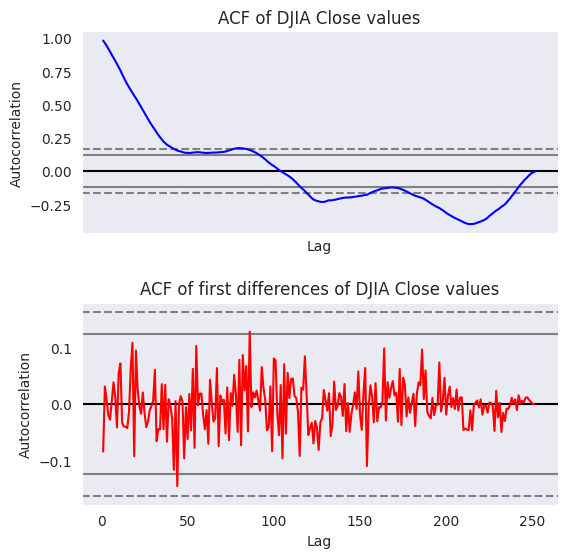

In [ ]:
fig, ax = plt.subplots(2, sharex=True)
fig.set_size_inches(5.5, 5.5)
autocorrelation_plot(djia_df['Close'], color='b', ax=ax[0])
ax[0].set_title('ACF of DJIA Close values')
autocorrelation_plot(first_order_diff.iloc[1:], color='r', ax=ax[1])
ax[1].set_title('ACF of first differences of DJIA Close values')
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=2.0)

In [ ]:
acf_djia, confint_djia, qstat_djia, pvalues_djia = stattools.acf(djia_df['Close'],
                                                                 nlags=20,
                                                                 qstat=True,
                                                                 alpha=0.05)

In [ ]:
alpha = 0.05
for l, p_val in enumerate(pvalues_djia):
    if p_val > alpha:
        print('Null hypothesis is accepted at lag = {} for p-val = {}'.format(l, p_val))
    else:
        print('Null hypothesis is rejected at lag = {} for p-val = {}'.format(l, p_val))

Null hypothesis is rejected at lag = 0 for p-val = 2.8575062763850937e-55
Null hypothesis is rejected at lag = 1 for p-val = 1.7871763971270235e-105
Null hypothesis is rejected at lag = 2 for p-val = 9.927155881909393e-154
Null hypothesis is rejected at lag = 3 for p-val = 8.084096278833678e-200
Null hypothesis is rejected at lag = 4 for p-val = 9.125287802248515e-244
Null hypothesis is rejected at lag = 5 for p-val = 1.0907828815950437e-285
Null hypothesis is rejected at lag = 6 for p-val = 0.0
Null hypothesis is rejected at lag = 7 for p-val = 0.0
Null hypothesis is rejected at lag = 8 for p-val = 0.0
Null hypothesis is rejected at lag = 9 for p-val = 0.0
Null hypothesis is rejected at lag = 10 for p-val = 0.0
Null hypothesis is rejected at lag = 11 for p-val = 0.0
Null hypothesis is rejected at lag = 12 for p-val = 0.0
Null hypothesis is rejected at lag = 13 for p-val = 0.0
Null hypothesis is rejected at lag = 14 for p-val = 0.0
Null hypothesis is rejected at lag = 15 for p-val = 0.

In [ ]:
acf_first_diff, confint_first_diff,\
qstat_first_diff, pvalues_first_diff = stattools.acf(first_order_diff.iloc[1:],
                                                     nlags=20,
                                                     qstat=True,
                                                     alpha=0.05)

In [ ]:
alpha = 0.05
for l, p_val in enumerate(pvalues_first_diff):
    if p_val > alpha:
        print('Null hypothesis is accepted at lag = {} for p-val = {}'.format(l, p_val))
    else:
        print('Null hypothesis is rejected at lag = {} for p-val = {}'.format(l, p_val))

Null hypothesis is accepted at lag = 0 for p-val = 0.17742519268365275
Null hypothesis is accepted at lag = 1 for p-val = 0.3571107471719485
Null hypothesis is accepted at lag = 2 for p-val = 0.5569664476694902
Null hypothesis is accepted at lag = 3 for p-val = 0.7025937592112146
Null hypothesis is accepted at lag = 4 for p-val = 0.7937258941281415
Null hypothesis is accepted at lag = 5 for p-val = 0.8806452939902653
Null hypothesis is accepted at lag = 6 for p-val = 0.9058055508095896
Null hypothesis is accepted at lag = 7 for p-val = 0.9461503874902826
Null hypothesis is accepted at lag = 8 for p-val = 0.9529107001186854
Null hypothesis is accepted at lag = 9 for p-val = 0.9452880323047997
Null hypothesis is accepted at lag = 10 for p-val = 0.9103701842715781
Null hypothesis is accepted at lag = 11 for p-val = 0.9303312940619602
Null hypothesis is accepted at lag = 12 for p-val = 0.9412519715905938
Null hypothesis is accepted at lag = 13 for p-val = 0.949888210486783
Null hypothesis 

In [ ]:
daily_temp = pd.read_excel('/content/drive/MyDrive/Analisis y Predicción de series de tiempo/Data/mean-daily-temperature-fisher-river.xlsx')
daily_temp.head()

,Date,Mean_Temperature
0,1988-01-01,-23.0
1,1988-01-02,-20.5
2,1988-01-03,-22.0
3,1988-01-04,-30.5
4,1988-01-05,-31.0


In [ ]:
daily_temp.index = daily_temp['Date'].map(lambda date: pd.to_datetime(date, '%Y-%m-%d'))
daily_temp.drop('Date', axis=1, inplace=True)
daily_temp.head()

,Mean_Temperature
Date,
1988-01-01,-23.0
1988-01-02,-20.5
1988-01-03,-22.0
1988-01-04,-30.5
1988-01-05,-31.0


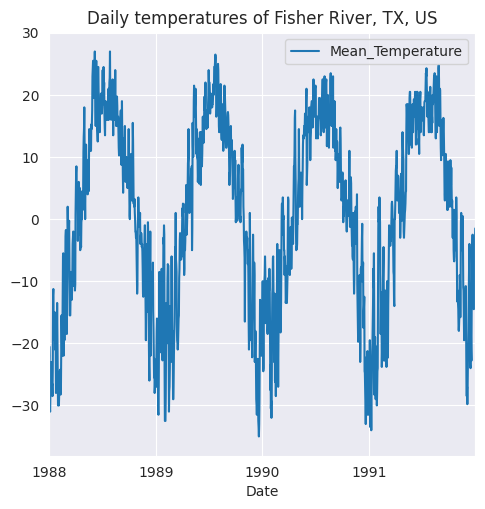

In [ ]:
fig = plt.figure(figsize=(5.5, 5.5))
ax = fig.add_subplot(1,1,1)
ax.set_title('Daily temperatures of Fisher River, TX, US');
daily_temp.plot(ax=ax);

In [ ]:
montly_resample = daily_temp['Mean_Temperature'].resample('M')
monthly_mean_temp = montly_resample.mean()
print('Shape of monthly mean temperature dataset:', monthly_mean_temp.shape)
monthly_mean_temp.head()

Shape of monthly mean temperature dataset: (48,)


,Mean_Temperature
Date,
1988-01-31,-22.137097
1988-02-29,-19.025862
1988-03-31,-8.258065
1988-04-30,2.641667
1988-05-31,11.290323


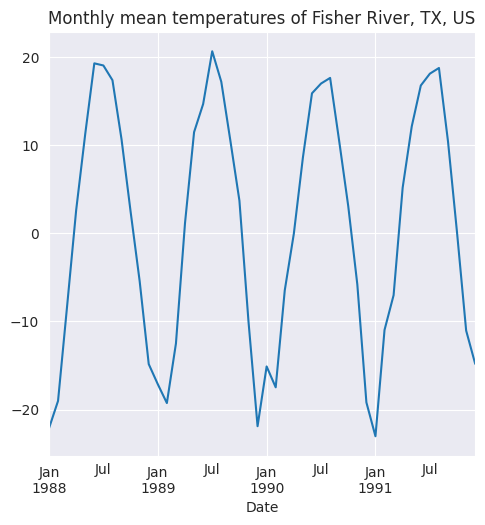

In [ ]:
fig = plt.figure(figsize=(5.5, 5.5))
ax = fig.add_subplot(1,1,1)
ax.set_title('Monthly mean temperatures of Fisher River, TX, US')
monthly_mean_temp.plot(ax=ax);

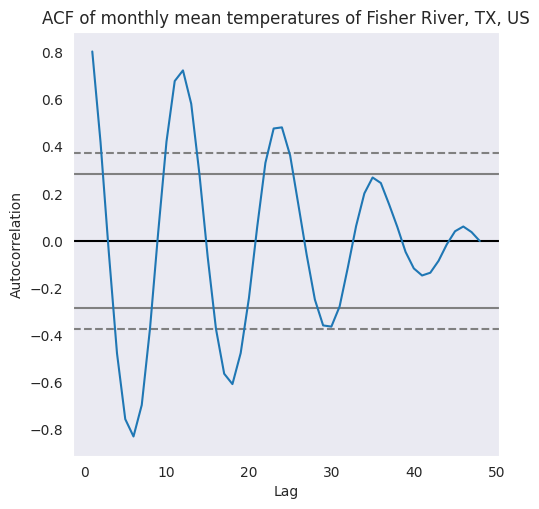

In [ ]:
fig = plt.figure(figsize=(5.5, 5.5))
ax = fig.add_subplot(1,1,1)
ax.set_title('ACF of monthly mean temperatures of Fisher River, TX, US')
autocorrelation_plot(monthly_mean_temp, ax=ax);

In [ ]:
seasonal_diff = monthly_mean_temp.diff(12)
seasonal_diff = seasonal_diff[12:]

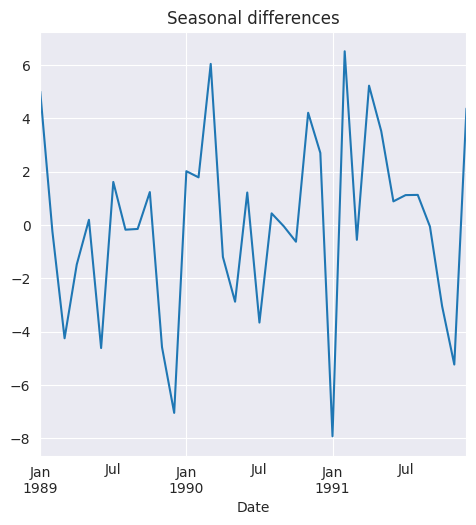

In [ ]:
fig = plt.figure(figsize=(5.5, 5.5))
ax = fig.add_subplot(1,1,1)
ax.set_title('Seasonal differences');
seasonal_diff.plot(ax=ax);

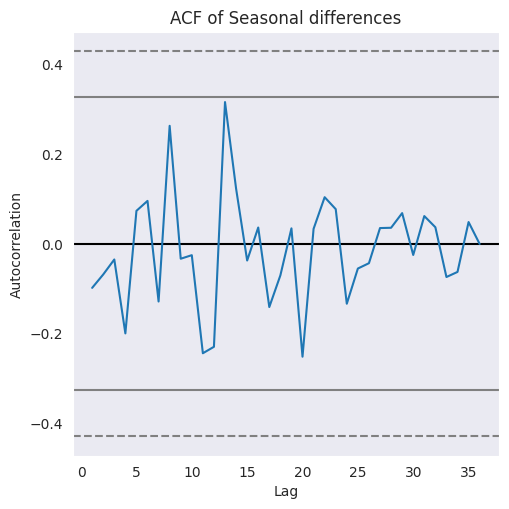

In [ ]:
fig = plt.figure(figsize=(5.5, 5.5))
ax = fig.add_subplot(1,1,1)
ax.set_title('ACF of Seasonal differences');
autocorrelation_plot(seasonal_diff, ax=ax);

In [ ]:
_, _, _, pval_monthly_mean = stattools.acf(monthly_mean_temp,
                                           nlags=10,
                                           qstat=True,
                                           alpha=0.05)
print('Null hypothesis is rejected for lags:', np.where(pval_monthly_mean<=0.05))

Null hypothesis is rejected for lags: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),)


In [ ]:
_, _, _, pval_monthly_mean = stattools.acf(monthly_mean_temp,
                                           nlags=10,
                                           qstat=True,
                                           alpha=0.05)
print('Null hypothesis is rejected for lags:', np.where(pval_monthly_mean<=0.05))

Null hypothesis is rejected for lags: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),)


## **1.29. Prueba de Dickey-Fuller**

In [ ]:
air_miles = pd.read_csv('/content/drive/MyDrive/Analisis y Predicción de series de tiempo/Data/us-airlines-monthly-aircraft-miles-flown.csv')
air_miles.index = air_miles.Month

In [ ]:
print('Shape of the DataFrame:', air_miles.shape)
air_miles.head()

Shape of the DataFrame: (97, 2)


,Month,U.S. airlines: monthly aircraft miles flown (Millions) 1963 -1970
Month,,
1963-01,1963-01,6827.0
1963-02,1963-02,6178.0
1963-03,1963-03,7084.0
1963-04,1963-04,8162.0
1963-05,1963-05,8462.0


In [ ]:
air_miles.rename(columns={'U.S. airlines: monthly aircraft miles flown (Millions) 1963 -1970':\
                          'Air miles flown'}, inplace=True)

In [ ]:
missing = pd.isnull(air_miles['Air miles flown'])
print('Number of missing values found:', missing.sum())
air_miles = air_miles.loc[~missing, :]

Number of missing values found: 1


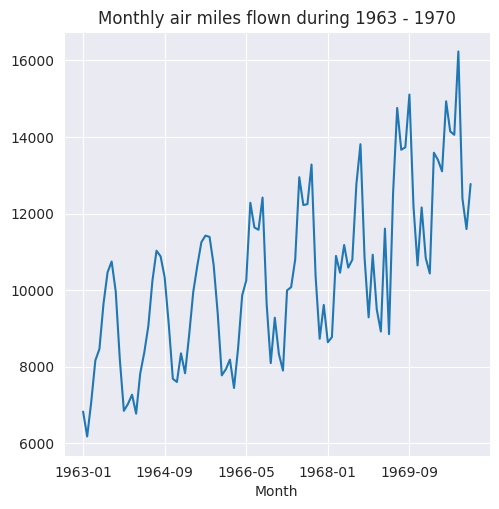

In [ ]:
fig = plt.figure(figsize=(5.5, 5.5))
ax = fig.add_subplot(1,1,1)
air_miles['Air miles flown'].plot(ax=ax)
ax.set_title('Monthly air miles flown during 1963 - 1970');

In [ ]:
adf_result = stattools.adfuller(air_miles['Air miles flown'], autolag='AIC')

In [ ]:
print('p-val of the ADF test in air miles flown:', adf_result[1])

p-val of the ADF test in air miles flown: 0.9945022811234028


## **1.31. Medias móviles y efectos de suavización**

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt

In [ ]:
ibm_df = pd.read_csv('/content/drive/MyDrive/Analisis y Predicción de series de tiempo/Data/ibm-common-stock-closing-prices.csv')
ibm_df.index = ibm_df['Date']

In [ ]:
print('Shape of the dataframe:', ibm_df.shape)
ibm_df.head()

Shape of the dataframe: (1009, 2)


,Date,IBM common stock closing prices
Date,,
1962-01-02,1962-01-02,572.00
1962-01-03,1962-01-03,577.00
1962-01-04,1962-01-04,571.25
1962-01-05,1962-01-05,560.00
1962-01-08,1962-01-08,549.50


In [ ]:
ibm_df.rename(columns={'IBM common stock closing prices': 'Close_Price'}, inplace=True)
ibm_df.head()

,Date,Close_Price
Date,,
1962-01-02,1962-01-02,572.00
1962-01-03,1962-01-03,577.00
1962-01-04,1962-01-04,571.25
1962-01-05,1962-01-05,560.00
1962-01-08,1962-01-08,549.50


In [ ]:
missing = (pd.isnull(ibm_df['Date'])) & (pd.isnull(ibm_df['Close_Price']))
print('No. of rows with missing values:', missing.sum())
ibm_df = ibm_df.loc[~missing, :]

No. of rows with missing values: 0


In [ ]:
ibm_df['5-Day Moving Avg'] = ibm_df['Close_Price'].rolling(5).mean()

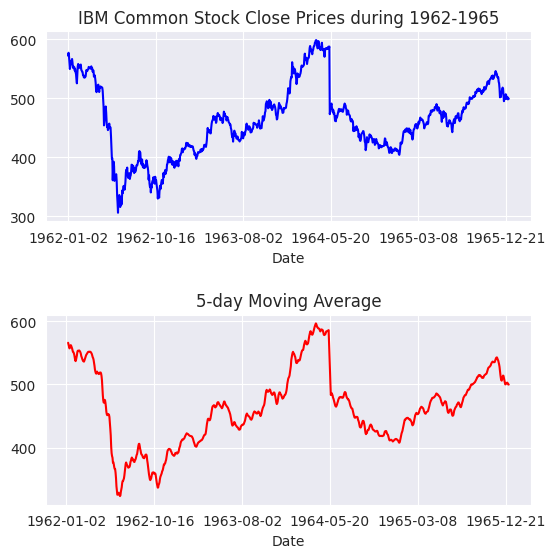

In [ ]:
fig = plt.figure(figsize=(5.5, 5.5))
ax = fig.add_subplot(2,1,1)
ibm_df['Close_Price'].plot(ax=ax, color='b')
ax.set_title('IBM Common Stock Close Prices during 1962-1965')
ax = fig.add_subplot(2,1,2)
ibm_df['5-Day Moving Avg'].plot(ax=ax, color='r')
ax.set_title('5-day Moving Average')
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=2.0)

In [ ]:
MA2 = ibm_df['Close_Price'].rolling(window=2).mean()
TwoXMA2 = MA2.rolling(window=2).mean()

MA4 = ibm_df['Close_Price'].rolling(window=4).mean()
TwoXMA4 = MA4.rolling(window=2).mean()

MA3 = ibm_df['Close_Price'].rolling(window=3).mean()
ThreeXMA3 = MA3.rolling(window=3).mean()

In [ ]:
TwoXMA2 = MA2.dropna()
TwoXMA4 = MA4.dropna()
ThreeXMA3 = MA3.dropna()

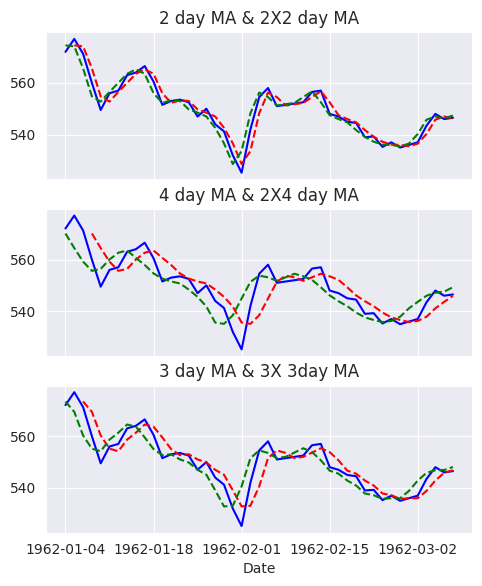

In [ ]:
f, axarr = plt.subplots(3, sharex=True)
f.set_size_inches(5.5, 6.5)

ibm_df['Close_Price'].iloc[:45].plot(color='b', linestyle = '-', ax=axarr[0])
MA2.iloc[:45].plot(color='r', linestyle = '--', ax=axarr[0])
TwoXMA2.iloc[:45].plot(color='g', linestyle = '--', ax=axarr[0])
axarr[0].set_title('2 day MA & 2X2 day MA');

ibm_df['Close_Price'].iloc[:45].plot(color='b', linestyle = '-', ax=axarr[1])
MA4.iloc[:45].plot(color='r', linestyle = '--', ax=axarr[1])
TwoXMA4.iloc[:45].plot(color='g', linestyle = '--', ax=axarr[1])
axarr[1].set_title('4 day MA & 2X4 day MA');

ibm_df['Close_Price'].iloc[:45].plot(color='b', linestyle = '-', ax=axarr[2])
MA3.iloc[:45].plot(color='r', linestyle = '--', ax=axarr[2])
ThreeXMA3.iloc[:45].plot(color='g', linestyle = '--', ax=axarr[2])
axarr[2].set_title('3 day MA & 3X 3day MA');

## **1.32. Ajuste estacional mediante media móvil**

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt

In [ ]:
beer_df = pd.read_csv('/content/drive/MyDrive/Analisis y Predicción de series de tiempo/Data/quarterly-beer-production-in-aus-March 1956-June 1994.csv')
beer_df.index = beer_df['Quarter']

In [ ]:
print('Shape of the dataframe:', beer_df.shape)
beer_df.head()

Shape of the dataframe: (155, 2)


,Quarter,Quarterly beer production in Australia: megalitres. March 1956 ? June 1994
Quarter,,
1956Q1,1956Q1,284.4
1956Q2,1956Q2,212.8
1956Q3,1956Q3,226.9
1956Q4,1956Q4,308.4
1957Q1,1957Q1,262.0


In [ ]:
beer_df.rename(columns={'Quarterly beer production in Australia: megalitres. March 1956 ? June 1994':'Beer_Prod'},
               inplace=True)

In [ ]:
missing = (pd.isnull(beer_df['Quarter'])) | (pd.isnull(beer_df['Beer_Prod']))
print('Number of rows with at least one missing values:', missing.sum())
beer_df = beer_df.loc[~missing, :]
print('Shape after removing missing values:', beer_df.shape)

Number of rows with at least one missing values: 1
Shape after removing missing values: (154, 2)


In [ ]:
MA4 = beer_df['Beer_Prod'].rolling(window=4).mean()
TwoXMA4 = MA4.rolling(window=2).mean()
TwoXMA4 = TwoXMA4.loc[~pd.isnull(TwoXMA4)]

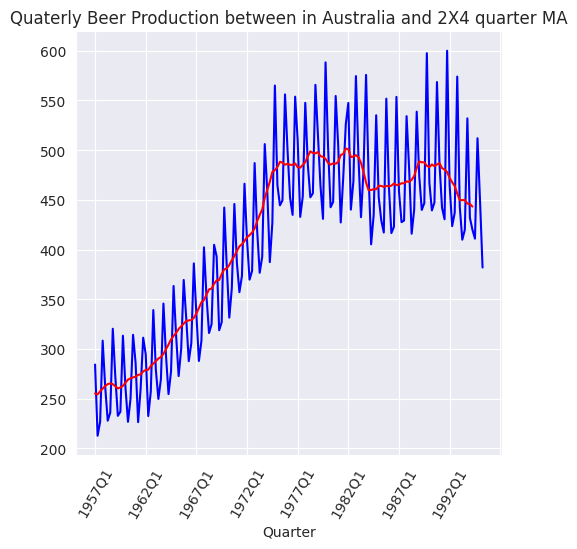

In [ ]:
fig = plt.figure(figsize=(5.5, 5.5))
ax = fig.add_subplot(1,1,1)
beer_df['Beer_Prod'].plot(ax=ax, color='b', linestyle='-')
TwoXMA4.plot(ax=ax, color='r', linestyle='-')
plt.xticks(rotation=60);
ax.set_title('Quaterly Beer Production between in Australia and 2X4 quarter MA');

In [ ]:
residuals = beer_df['Beer_Prod']-TwoXMA4
residuals = residuals.loc[~pd.isnull(residuals)]

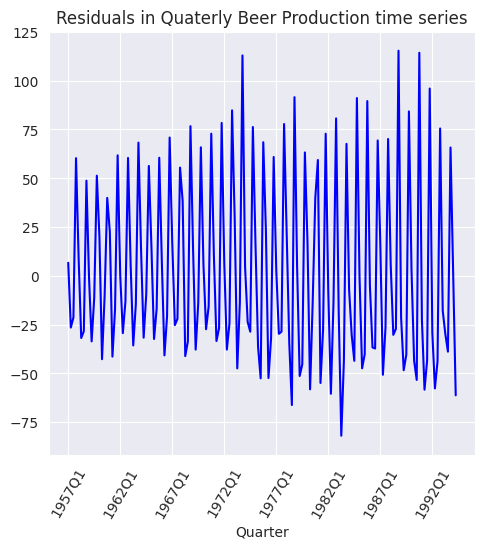

In [ ]:
fig = plt.figure(figsize=(5.5, 5.5))
ax = fig.add_subplot(1,1,1)
residuals.plot(ax=ax, color='b', linestyle='-')
plt.xticks(rotation=60);
ax.set_title('Residuals in Quaterly Beer Production time series');

In [ ]:
from pandas.plotting import autocorrelation_plot

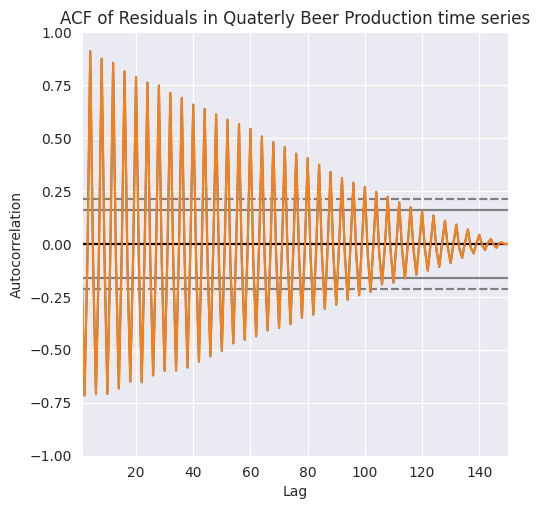

In [ ]:
fig = plt.figure(figsize=(5.5, 5.5))
ax = fig.add_subplot(1,1,1)
autocorrelation_plot(residuals, ax=ax)
ax.set_title('ACF of Residuals in Quaterly Beer Production time series');
autocorrelation_plot(residuals);

In [ ]:
residuals_qtr_diff = np.log(residuals.diff(4))

In [ ]:
residuals_qtr_diff = residuals_qtr_diff.loc[~pd.isnull(residuals_qtr_diff)]

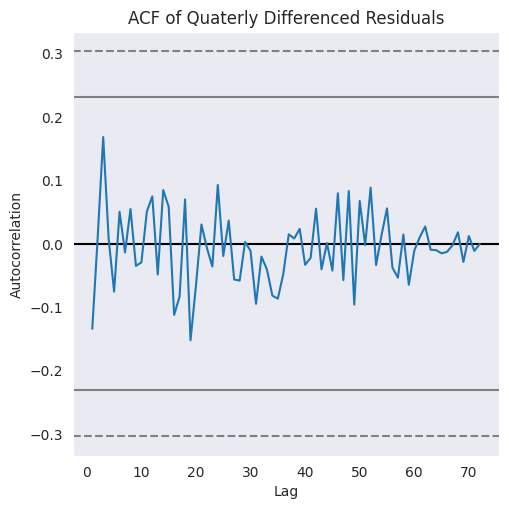

In [ ]:
fig = plt.figure(figsize=(5.5, 5.5))
ax = fig.add_subplot(1,1,1)
autocorrelation_plot(residuals_qtr_diff, ax=ax)
ax.set_title('ACF of Quaterly Differenced Residuals');

In [ ]:
_, _, _, pval_monthly_mean = stattools.acf(residuals_qtr_diff,
                                           nlags=10,
                                           qstat=True,
                                           alpha=0.05)
print('Null hypothesis is rejected for lags:', np.where(pval_monthly_mean<=0.05))

Null hypothesis is rejected for lags: (array([], dtype=int64),)


## **1.34. Descomposición de series temporales mediante medias móviles**

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa import stattools
from matplotlib import pyplot as plt

In [ ]:
air_miles = pd.read_csv('/content/drive/MyDrive/Analisis y Predicción de series de tiempo/Data/us-airlines-monthly-aircraft-miles-flown.csv')
air_miles.index = air_miles['Month']

In [ ]:
print('Shape of the DataFrame:', air_miles.shape)
air_miles.head()

Shape of the DataFrame: (97, 2)


,Month,U.S. airlines: monthly aircraft miles flown (Millions) 1963 -1970
Month,,
1963-01,1963-01,6827.0
1963-02,1963-02,6178.0
1963-03,1963-03,7084.0
1963-04,1963-04,8162.0
1963-05,1963-05,8462.0


In [ ]:
air_miles.rename(columns={'U.S. airlines: monthly aircraft miles flown (Millions) 1963 -1970': 'Air miles flown'},
                 inplace=True)
air_miles.head()

,Month,Air miles flown
Month,,
1963-01,1963-01,6827.0
1963-02,1963-02,6178.0
1963-03,1963-03,7084.0
1963-04,1963-04,8162.0
1963-05,1963-05,8462.0


In [ ]:
missing = pd.isnull(air_miles['Air miles flown'])
print('Number of missing values found:', missing.sum())
air_miles = air_miles.loc[~missing, :]

Number of missing values found: 1


In [ ]:
MA12 = air_miles['Air miles flown'].rolling(window=12).mean()
trendComp = MA12.rolling(window=2).mean()

In [ ]:
residuals = air_miles['Air miles flown'] - trendComp

month = air_miles['Month'].map(lambda d: d[-2:])
monthwise_avg = residuals.groupby(by=month).aggregate(['mean'])
nb_years = 1970-1963+1

seasonalComp = np.array([monthwise_avg.values]*nb_years).reshape((12*nb_years,))

In [ ]:
irr_var = air_miles['Air miles flown'] - trendComp - seasonalComp

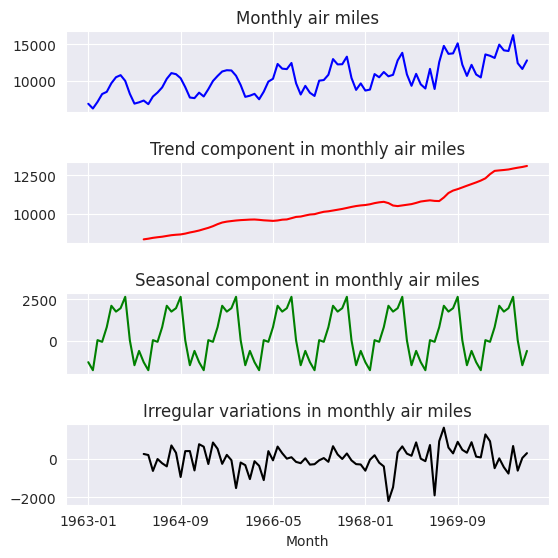

In [ ]:
fig, axarr = plt.subplots(4, sharex=True)
fig.set_size_inches(5.5, 5.5)

air_miles['Air miles flown'].plot(ax=axarr[0], color='b', linestyle='-')
axarr[0].set_title('Monthly air miles')

pd.Series(data=trendComp, index=air_miles.index).plot(ax=axarr[1], color='r', linestyle='-')
axarr[1].set_title('Trend component in monthly air miles')

pd.Series(data=seasonalComp, index=air_miles.index).plot(ax=axarr[2], color='g', linestyle='-')
axarr[2].set_title('Seasonal component in monthly air miles')

pd.Series(data=irr_var, index=air_miles.index).plot(ax=axarr[3], color='k', linestyle='-')
axarr[3].set_title('Irregular variations in monthly air miles')

plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=2.0)

In [ ]:
adf_result = stattools.adfuller(irr_var.loc[~pd.isnull(irr_var)], autolag='AIC')
print('p-val of the ADF test on irregular variations in air miles flown:', adf_result[1])

p-val of the ADF test on irregular variations in air miles flown: 0.06577411025730036


In [ ]:
residuals = air_miles['Air miles flown'] / trendComp

In [ ]:
month = air_miles['Month'].map(lambda d: d[-2:])
monthwise_avg = residuals.groupby(by=month).aggregate(['mean'])
nb_years = 1970-1963+1

seasonalComp = np.array([monthwise_avg.values]*nb_years).reshape((12*nb_years,))

In [ ]:
irr_var = air_miles['Air miles flown'] / (trendComp * seasonalComp)

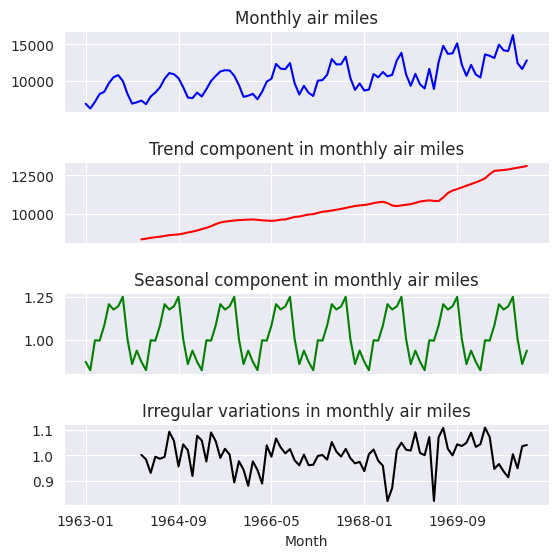

In [ ]:
fig, axarr = plt.subplots(4, sharex=True)
fig.set_size_inches(5.5, 5.5)

air_miles['Air miles flown'].plot(ax=axarr[0], color='b', linestyle='-')
axarr[0].set_title('Monthly air miles')

pd.Series(data=trendComp, index=air_miles.index).plot(ax=axarr[1], color='r', linestyle='-')
axarr[1].set_title('Trend component in monthly air miles')

pd.Series(data=seasonalComp, index=air_miles.index).plot(ax=axarr[2], color='g', linestyle='-')
axarr[2].set_title('Seasonal component in monthly air miles')

pd.Series(data=irr_var, index=air_miles.index).plot(ax=axarr[3], color='k', linestyle='-')
axarr[3].set_title('Irregular variations in monthly air miles')

plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=2.0)

In [ ]:
adf_result = stattools.adfuller(irr_var.loc[~pd.isnull(irr_var)], autolag='AIC')
print('p-val of the ADF test on irregular variations in air miles flown:', adf_result[1])

p-val of the ADF test on irregular variations in air miles flown: 0.0001764528090837097


## **1.35. Descomposición de series temporales mediante** *statsmodels.tsa*

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa import stattools
from statsmodels.tsa import seasonal
from matplotlib import pyplot as plt

In [ ]:
wisc_emp = pd.read_csv('/content/drive/MyDrive/Analisis y Predicción de series de tiempo/Data/wisconsin-employment-time-series.csv')
wisc_emp.index = wisc_emp['Month']

In [ ]:
print('Shape of the DataFrame:', wisc_emp.shape)
wisc_emp.head(10)

Shape of the DataFrame: (178, 2)


,Month,Employment
Month,,
1961-01,1961-01,239.6
1961-02,1961-02,236.4
1961-03,1961-03,236.8
1961-04,1961-04,241.5
1961-05,1961-05,243.7
1961-06,1961-06,246.1
1961-07,1961-07,244.1
1961-08,1961-08,244.2
1961-09,1961-09,244.8


In [ ]:
missing = (pd.isnull(wisc_emp['Employment'])) | (pd.isnull(wisc_emp['Month']))
print('Number of missing values found:', missing.sum())
wisc_emp = wisc_emp.loc[~missing, :]

Number of missing values found: 0


In [ ]:
adf_result = stattools.adfuller(wisc_emp['Employment'], autolag='AIC')
print('p-val of the ADF test on irregular variations in employment data:', adf_result[1])

p-val of the ADF test on irregular variations in employment data: 0.9810000189539191


In [ ]:
decompose_model = seasonal.seasonal_decompose(wisc_emp.Employment.tolist(), period=12, model='additive')

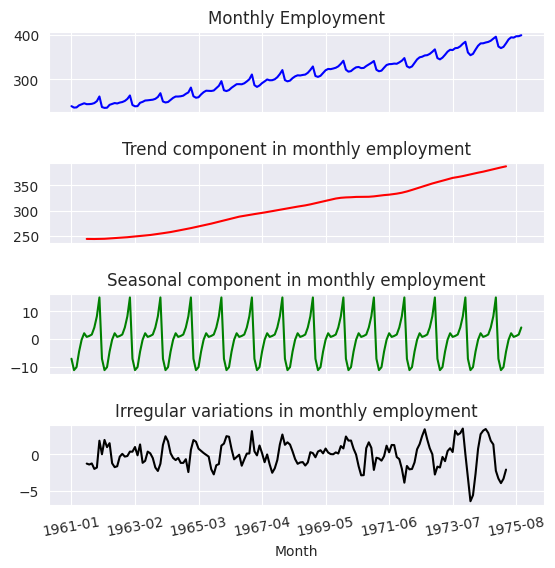

In [ ]:
fig, axarr = plt.subplots(4, sharex=True)
fig.set_size_inches(5.5, 5.5)

wisc_emp['Employment'].plot(ax=axarr[0], color='b', linestyle='-')
axarr[0].set_title('Monthly Employment')

pd.Series(data=decompose_model.trend, index=wisc_emp.index).plot(color='r', linestyle='-', ax=axarr[1])
axarr[1].set_title('Trend component in monthly employment')

pd.Series(data=decompose_model.seasonal, index=wisc_emp.index).plot(color='g', linestyle='-', ax=axarr[2])
axarr[2].set_title('Seasonal component in monthly employment')

pd.Series(data=decompose_model.resid, index=wisc_emp.index).plot(color='k', linestyle='-', ax=axarr[3])
axarr[3].set_title('Irregular variations in monthly employment')

plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=2.0);
plt.xticks(rotation=10);

In [ ]:
adf_result = stattools.adfuller(decompose_model.resid[np.where(np.isfinite(decompose_model.resid))[0]],
                                autolag='AIC')
print('p-val of the ADF test on irregular variations in employment data:', adf_result[1])

p-val of the ADF test on irregular variations in employment data: 0.006560931634641406


In [ ]:
decompose_model = seasonal.seasonal_decompose(wisc_emp.Employment.tolist(), period=12, model='multiplicative')

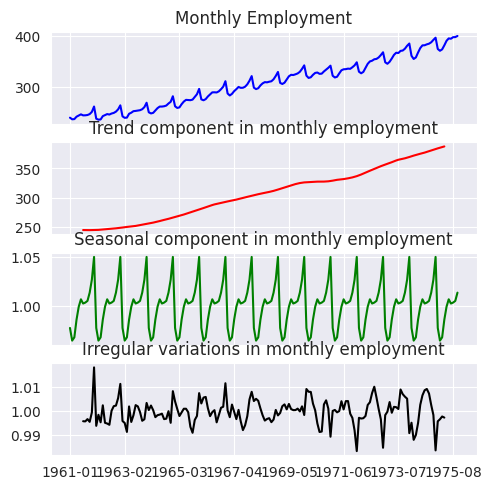

In [ ]:
fig, axarr = plt.subplots(4, sharex=True)
fig.set_size_inches(5.5, 5.5)

wisc_emp['Employment'].plot(ax=axarr[0], color='b', linestyle='-')
axarr[0].set_title('Monthly Employment');

axarr[1].plot(decompose_model.trend, color='r', linestyle='-')
axarr[1].set_title('Trend component in monthly employment');

axarr[2].plot(decompose_model.seasonal, color='g', linestyle='-')
axarr[2].set_title('Seasonal component in monthly employment');

axarr[3].plot(decompose_model.resid, color='k', linestyle='-')
axarr[3].set_title('Irregular variations in monthly employment');

In [ ]:
adf_result = stattools.adfuller(decompose_model.resid[np.where(np.isfinite(decompose_model.resid))[0]],
                                autolag='AIC')
print('p-val of the ADF test on irregular variations in employment data:', adf_result[1])

p-val of the ADF test on irregular variations in employment data: 0.0012347837267731921
